In [1]:
import city2graph as c2g
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np

import lonboard
from lonboard.colormap import apply_continuous_cmap
from lonboard.basemap import MaplibreBasemap, CartoStyle

import pygris
from shapely.geometry import box
from shapely.geometry import Polygon

import pgeocode

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# pd.reset_option('display.max_rows')

In [3]:
bbox = [-106.235089,31.650698,-105.983214,31.834724]   # first define rough bounding box to make c2g fetch easy
# mask = box(*bbox)

data = c2g.load_overture_data(
    area=bbox,
    types=["building", "segment"],
    save_to_file=False
)

crs = next(iter(data.values())).estimate_utm_crs()
data = {k: v.to_crs(crs) for k, v in data.items()}

In [4]:
# traced a polygon in qgis to match horizon subdivision maps, this will be the clipping mask
mask_gdf = gpd.read_file('geodata_clean/horizon-city-mask.geojson')
mask = mask_gdf.geometry.iloc[0]   # grabs the single polygon geometry rather than the whole geometry column/series

buildings = data["building"].to_crs(4326).clip(mask)

# to avoid tiny clipped road fragments (annoying for viz), filter out segments shorter than some length
segments_masked = data["segment"].to_crs(4326).clip(mask)    # first clip to mask (in 4326)
segments_projected = segments_masked.to_crs(32613)   # relevant projected CRS for measurements
segments = segments_projected[segments_projected.geometry.length > 10].to_crs(4326)    # filter out segments <10 m

tiger_roads = pygris.roads(state="TX", county="El Paso", year=2025).to_crs(4326).clip(mask)   # comparison road dataset, in case needed

Using FIPS code '48' for input 'TX'
Using FIPS code '141' for input 'El Paso'


In [5]:
# to avoid slivers of outside-bounds parcels included inside the mask (will mess with analysis), we'll include only parcels with most area inside the mask

parcels_projected = gpd.read_file("geodata_raw/tx_el_paso.gpkg").to_crs(32613)   # relevant projected CRS for measurements
mask_projected = gpd.GeoSeries([mask], crs='EPSG:4326').to_crs(32613).iloc[0]

# calculate what percent of each parcel's original area falls inside the mask
parcels_projected['original_area'] = parcels_projected.geometry.area
parcels_projected['clipped_geometry'] = parcels_projected.geometry.intersection(mask_projected)
parcels_projected['clipped_area'] = parcels_projected['clipped_geometry'].area
parcels_projected['pct_inside'] = parcels_projected['clipped_area'] / parcels_projected['original_area']

# keep parcels that are 75% inside the mask
parcels = parcels_projected[parcels_projected['pct_inside'] > 0.75]
parcels = parcels.drop(columns=['geometry']).set_geometry('clipped_geometry').to_crs(4326)

In [6]:
parcel_layer = lonboard.PolygonLayer.from_geopandas(
    parcels,
    get_fill_color=[255, 137, 47, 30],   
    get_line_color=[180, 90, 0, 220],
    line_width_min_pixels=1
)

building_layer = lonboard.PolygonLayer.from_geopandas(
    buildings,
    get_fill_color=[13, 122, 116, 180],  
    get_line_color=[13, 122, 116, 255],      
    line_width_min_pixels=1
)

overture_road_layer = lonboard.PathLayer.from_geopandas(
    segments,
    get_color=[55, 48, 163, 200],             
    get_width=2,                         
    width_min_pixels=1                   
)

lonboard.Map(
    layers=[parcel_layer, building_layer, overture_road_layer]
)

In [17]:
buildings.to_file('geodata_clean/horizon-city-buildings.gpkg', driver='GPKG')
segments.to_file('geodata_clean/horizon-city-overture-roads.gpkg', driver='GPKG')
tiger_roads.to_file('geodata_clean/horizon-city-tiger-roads.gpkg', driver='GPKG')
parcels.to_file('geodata_clean/horizon-city-parcels.gpkg', driver='GPKG')

## Workflow for analysis

Double-outlined boxes = save as gpkg

```mermaid
---
config:
  layout: elk
  look: handDrawn
---
graph TD;
    parcels[[parcels]]-->residential[residential]
    residential-->sold-unbuilt[[sold-unbuilt]]
    residential-->built
    residential-->unsold
    sold-unbuilt-->individuals[[individuals]]
    sold-unbuilt-->HCIA[[HCIA]]
    sold-unbuilt-->entities
    individuals-->US["US, geocoded"]
    individuals-->international[[international]]
    US-->USall[["US all rows, parcel geometry"]] & USunique[["US unique, owner geometry"]]
    international-->intunique[["international unique"]]
```

In [7]:
parcels.sample(n=5)

,geoid,parcelnumb,parcelnumb_no_formatting,state_parcelnumb,account_number,tax_id,alt_parcelnumb1,alt_parcelnumb2,alt_parcelnumb3,usecode,usedesc,zoning,zoning_description,struct,structno,yearbuilt,year_built_effective_date,numstories,numunits,numrooms,num_bath,num_bath_partial,num_bedrooms,structstyle,parvaltype,improvval,landval,parval,agval,saleprice,saledate,taxamt,taxyear,last_ownership_transfer_date,owntype,owner,unmodified_owner,ownfrst,ownlast,owner2,owner3,owner4,previous_owner,mailadd,mail_address2,careof,mail_addno,mail_addpref,mail_addstr,mail_addsttyp,mail_addstsuf,mail_unit,mail_city,mail_state2,mail_zip,mail_country,mail_urbanization,original_mailing_address,address,address2,saddno,saddpref,saddstr,saddsttyp,saddstsuf,sunit,scity,original_address,city,county,state2,szip,szip5,urbanization,location_name,address_source,legaldesc,plat,book,page,block,lot,neighborhood,neighborhood_code,subdivision,lat,lon,qoz,qoz_tract,census_tract,census_block,census_blockgroup,census_zcta,ll_last_refresh,sourceurl,recrdareatx,recrdareano,area_building,area_building_definition,deeded_acres,gisacre,sqft,ll_gisacre,ll_gissqft,plss_township,plss_section,plss_range,reviseddate,path,ll_stable_id,ll_uuid,ll_stack_uuid,ll_updated_at,pidn,altpid_1,altpid_2,altpid_3,altpid_4,altpid_5,city_owned,source,tile9_,date_,prop_id,tilesec,abs_subdv,imprv_det_,prop_val_y,geo_id,department,map_id,abs_subd_1,owner_id,ref_id2,school,college,water,emergency,municipal,situs_stat,exemptions,tif_zone_c,linked_acc,city_code,comments_,improvementhomesitevalue,improvementnonhomesitevalue,landnonhomesitevalue,landhomesitevalue,agriculturalortimberusevaluereduction,appraisedvalue,hscap,assessedvalue,original_area,clipped_geometry,clipped_area,pct_inside
285030,48141,238097,238097,None,None,None,H78404300200060,1048179,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,3.0,3.0,0.0,0.0,2016-08-23,NaN,2025,2016-08-23,None,THE ROBERT C GREEVES JR IRREVOCABLE TRUST,None,None,None,None,None,None,None,1412 BRAZOSPORT BLVD N,NaN,NaN,1412,NaN,BRAZOSPORT,BLVD,N,None,RICHWOOD,TX,77531-2843,None,None,"{""mailadd"":""1412 BRAZOSPORT BLVD N"",""mail_city...",NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""address"":"""",""szip"":""79938""}",el-paso-east,el-paso,TX,79938,79938,None,None,county,2 HORIZON CITY ESTATES #43 LOT 6 ( 11414.00 SQ...,None,None,None,None,None,None,None,None,31.770461,-106.154554,Yes,48141010344,48141010344,481410103441057,481410103441,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.2620,NaN,0.26197,11412,NaN,NaN,NaN,NaT,/us/tx/el-paso/el-paso-east/312801,parcelnumb,d1be70d9-b812-4904-9e5a-cefd1a4bb5bd,NaN,2026-03-27 04:45:14.213000+00:00,H78404300200060,NaN,NaN,NaN,NaN,NaN,NaN,t15d,7,NaN,238097.0,eastc04,H78443,NaN,2025.0,H78404300200060,Residential,NEB217,H78443,1048179,TDC85,ICL,SCC,NaN,SF2,SWE,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,3.0,0.0,0.0,3.0,0.0,3.0,1060.198165,"POLYGON ((-106.15474 31.77032, -106.15474 31.7...",1060.198165,1.0
50471,48141,398008,398008,None,None,None,S83802005100220,14951,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,1.0,1.0,0.0,0.0,1993-06-28,NaN,2025,NaT,None,CANALES YOLANDA,None,None,None,None,None,None,None,11838 PRISCILLA CIR,NaN,NaN,11838,NaN,PRISCILLA,CIR,NaN,None,EL PASO,TX,79936-6727,None,None,"{""mailadd"":""11838 PRISCILLA CIR"",""mail_city"":""...",NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""address"":"""",""szip"":""79928""}",el-paso-east,el-paso,TX,79928,79928,None,None,county,51 SUNLAND ESTATES #20 LOT 22 ( 6000.00 SQ FT),None,None,None,None,None,None,None,None,31.667964,-106.032655,Yes,48141010344,48141010335,481410103351000,481410103351,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.1377,NaN,0.13752,5991,NaN,NaN,NaN,NaT,/us/tx/el-paso/el-paso-east/58929,parcelnumb,1f8bc361-15d7-4871-8652-3bb749605a60,NaN,2026-03-27 04:45:14.213000+00:00,S83802005100220,NaN,NaN,NaN,NaN,NaN,NaN,t21b,7,NaN,398008.0,eastc07,S83820,NaN,2025.0,S83802005100220,Residential,SEA114,S83820,14951,TDC62,IC

In [8]:
parcels.dtypes.to_list

<bound method IndexOpsMixin.tolist of geoid                                                    str
parcelnumb                                               str
parcelnumb_no_formatting                                 str
state_parcelnumb                                      object
account_number                                        object
tax_id                                                object
alt_parcelnumb1                                          str
alt_parcelnumb2                                          str
alt_parcelnumb3                                       object
usecode                                                  str
usedesc                                               object
zoning                                                   str
zoning_description                                       str
struct                                               float64
structno                                             float64
yearbuilt                                      

In [9]:
len(parcels)

100731

In [10]:
parcels['department'].value_counts()

department
Residential    99807
Commercial       497
Name: count, dtype: int64

In [11]:
parcels['department'].isna().sum()

np.int64(427)

In [12]:
parcels[parcels['department'].isna()].head()

# ok, NaN seem to be city resources/something not residential parcel

,geoid,parcelnumb,parcelnumb_no_formatting,state_parcelnumb,account_number,tax_id,alt_parcelnumb1,alt_parcelnumb2,alt_parcelnumb3,usecode,usedesc,zoning,zoning_description,struct,structno,yearbuilt,year_built_effective_date,numstories,numunits,numrooms,num_bath,num_bath_partial,num_bedrooms,structstyle,parvaltype,improvval,landval,parval,agval,saleprice,saledate,taxamt,taxyear,last_ownership_transfer_date,owntype,owner,unmodified_owner,ownfrst,ownlast,owner2,owner3,owner4,previous_owner,mailadd,mail_address2,careof,mail_addno,mail_addpref,mail_addstr,mail_addsttyp,mail_addstsuf,mail_unit,mail_city,mail_state2,mail_zip,mail_country,mail_urbanization,original_mailing_address,address,address2,saddno,saddpref,saddstr,saddsttyp,saddstsuf,sunit,scity,original_address,city,county,state2,szip,szip5,urbanization,location_name,address_source,legaldesc,plat,book,page,block,lot,neighborhood,neighborhood_code,subdivision,lat,lon,qoz,qoz_tract,census_tract,census_block,census_blockgroup,census_zcta,ll_last_refresh,sourceurl,recrdareatx,recrdareano,area_building,area_building_definition,deeded_acres,gisacre,sqft,ll_gisacre,ll_gissqft,plss_township,plss_section,plss_range,reviseddate,path,ll_stable_id,ll_uuid,ll_stack_uuid,ll_updated_at,pidn,altpid_1,altpid_2,altpid_3,altpid_4,altpid_5,city_owned,source,tile9_,date_,prop_id,tilesec,abs_subdv,imprv_det_,prop_val_y,geo_id,department,map_id,abs_subd_1,owner_id,ref_id2,school,college,water,emergency,municipal,situs_stat,exemptions,tif_zone_c,linked_acc,city_code,comments_,improvementhomesitevalue,improvementnonhomesitevalue,landnonhomesitevalue,landhomesitevalue,agriculturalortimberusevaluereduction,appraisedvalue,hscap,assessedvalue,original_area,clipped_geometry,clipped_area,pct_inside
49256,48141,0,0,None,None,None,NaN,NaN,None,NaN,None,R-9,Single Family Dwelling,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,Horizon City,"{""address"":""""}",el-paso-east,el-paso,TX,79928,79928,None,None,"county,census_places",NaN,None,None,None,None,None,None,None,None,31.660062,-106.186870,No,NaN,48141010357,481410103572005,481410103572,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,NaN,NaN,0.04168,1816,NaN,NaN,NaN,NaT,/us/tx/el-paso/el-paso-east/57646,parcelnumb,0bdb9e4c-33f9-4904-9222-1afe71b8ece1,NaN,2026-04-22 17:32:29.936000+00:00,DRAINAGE ROW,NaN,NaN,NaN,NaN,D457,NaN,NaN,0,NaN,0.0,eastc06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,168.671181,"POLYGON ((-106.18689 31.6599, -106.18689 31.66...",168.671181,1.0
54878,48141,0,0,None,None,None,NaN,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""address"":""""}",el-paso-east,el-paso,TX,79928,79928,None,None,county,NaN,None,None,None,None,None,None,None,None,31.671829,-106.016592,Yes,48141010344,48141010335,481410103351000,481410103351,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,NaN,NaN,1.65172,71950,NaN,NaN,NaN,NaT,/us/tx/el-paso/el-paso-east/63494,parcelnumb,3c9f9055-222b-488b-9aa4-1bfeff86b2ed,NaN,2026-03-24 01:03:02.960000+00:00,S83800904700130,NaN,NaN,NaN,NaN,NaN,NaN,t21c,7,2011010,0.0,eastc07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6684.420872,"POLYGON ((-106.01676 31.67282, -106.01644 31.6...",6684.420872,1.0
225239,48141,575375,575375,None,None,None,NaN,NaN,None,NaN,None,R-9,Single Family Dwelling,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,Horizon City,"{""a

### Filter for **residential** parcels only, as we don't care about commercial or other

In [13]:
parcels = parcels[parcels['department'] == 'Residential']
len(parcels)

99807

### Filter for **sold and unbuilt** parcels

In [14]:
parcels['saleyear'] = parcels['saledate'].dt.year
parcels['saleyear'].value_counts().head()

saleyear
2000.0    27080
1995.0     9245
1981.0     3716
1980.0     3605
2011.0     3010
Name: count, dtype: int64

In [15]:
parcels[parcels['saleyear'] == 2000]['saledate'].value_counts().head()

# 2000 is likely so high due to clerical error - most are Jan 1

saledate
2000-01-01    26581
2000-08-04       11
2000-12-04       11
2000-08-15       11
2000-01-05        8
Name: count, dtype: int64

In [16]:
no_sale_date = parcels[parcels['saledate'].isna()]
len(no_sale_date)

5319

In [17]:
no_sale_date['owner'].value_counts().head()

# still plenty of owners for parcels without sale dates, so 'saledate' being notna or na isn't the best signifier of a sale

owner
UNKNOWN OWNER                3898
TOWN OF HORIZON CITY           35
CAVICO FRANK J JR (ET AL)      29
ITHACA DEVELOPMENT LLC         24
HCIA                           20
Name: count, dtype: int64

In [18]:
no_sale_date.sample(n=5)

# and even plenty of UNKNOWN OWNER have a mailing address/mailing city, so clearly still some sort of owner on record

,geoid,parcelnumb,parcelnumb_no_formatting,state_parcelnumb,account_number,tax_id,alt_parcelnumb1,alt_parcelnumb2,alt_parcelnumb3,usecode,usedesc,zoning,zoning_description,struct,structno,yearbuilt,year_built_effective_date,numstories,numunits,numrooms,num_bath,num_bath_partial,num_bedrooms,structstyle,parvaltype,improvval,landval,parval,agval,saleprice,saledate,taxamt,taxyear,last_ownership_transfer_date,owntype,owner,unmodified_owner,ownfrst,ownlast,owner2,owner3,owner4,previous_owner,mailadd,mail_address2,careof,mail_addno,mail_addpref,mail_addstr,mail_addsttyp,mail_addstsuf,mail_unit,mail_city,mail_state2,mail_zip,mail_country,mail_urbanization,original_mailing_address,address,address2,saddno,saddpref,saddstr,saddsttyp,saddstsuf,sunit,scity,original_address,city,county,state2,szip,szip5,urbanization,location_name,address_source,legaldesc,plat,book,page,block,lot,neighborhood,neighborhood_code,subdivision,lat,lon,qoz,qoz_tract,census_tract,census_block,census_blockgroup,census_zcta,ll_last_refresh,sourceurl,recrdareatx,recrdareano,area_building,area_building_definition,deeded_acres,gisacre,sqft,ll_gisacre,ll_gissqft,plss_township,plss_section,plss_range,reviseddate,path,ll_stable_id,ll_uuid,ll_stack_uuid,ll_updated_at,pidn,altpid_1,altpid_2,altpid_3,altpid_4,altpid_5,city_owned,source,tile9_,date_,prop_id,tilesec,abs_subdv,imprv_det_,prop_val_y,geo_id,department,map_id,abs_subd_1,owner_id,ref_id2,school,college,water,emergency,municipal,situs_stat,exemptions,tif_zone_c,linked_acc,city_code,comments_,improvementhomesitevalue,improvementnonhomesitevalue,landnonhomesitevalue,landhomesitevalue,agriculturalortimberusevaluereduction,appraisedvalue,hscap,assessedvalue,original_area,clipped_geometry,clipped_area,pct_inside,saleyear
71384,48141,358707,358707,None,None,None,H77902521500010,52117,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,1726.0,1726.0,0.0,NaN,NaT,NaN,2025,NaT,None,UNKNOWN OWNER,None,None,None,None,None,None,None,8075 SW 107TH AVE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MIAMI,FL,33173-4848,None,None,"{""mailadd"":""8075 SW 107TH AVE"",""mail_city"":""MI...",GIRARD AVE,None,NaN,NaN,GIRARD,AVE,NaN,NaN,CLINT,"{""address"":""GIRARD AVE"",""saddstr"":""GIRARD"",""sa...",el-paso-east,el-paso,TX,79928,79928,None,None,county,215 HORIZON CITY #25 1 & 2 ( 71915.00 SQ FT),None,None,None,None,None,None,None,None,31.688835,-106.073851,Yes,48141010344,48141010344,481410103441089,481410103441,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,1.6509,NaN,1.64935,71847,NaN,NaN,NaN,NaT,/us/tx/el-paso/el-paso-east/81966,parcelnumb,b61c6582-b362-48ff-849c-3b6bf056475d,NaN,2026-03-27 04:47:44.492000+00:00,H77902521500010,NaN,NaN,NaN,NaN,NaN,NaN,t22b,7,NaN,358707.0,eastc05,H77925,NaN,2025.0,H77902521500010,Residential,SEA90,H77925,52117,TDC62,ICL,SCC,NaN,SF1,SWE,TX,NaN,NaN,F,NaN,NaN,NaN,NaN,1726.0,0.0,0.0,1726.0,0.0,1726.0,6674.842471,"POLYGON ((-106.07385 31.6885, -106.07432 31.68...",6674.842471,1.0,NaN
247348,48141,63119,63119,None,None,None,M83104130500480,49777,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,240.0,240.0,0.0,NaN,NaT,NaN,2025,NaT,None,UNKNOWN OWNER,None,None,None,None,None,None,None,PO BOX 889,NaN,NaN,889,NaN,PO BOX,NaN,NaN,None,SEVERNA PARK,MD,21146-0889,None,None,"{""mailadd"":""PO BOX 889"",""mail_city"":""SEVERNA P...",MONARCH AVE,None,NaN,NaN,MONARCH,AVE,NaN,NaN,CLINT,"{""address"":""MONARCH AVE"",""saddstr"":""MONARCH"",""...",el-paso-east,el-paso,TX,79928,79928,None,None,county,305 MOUNTAIN SHADOW ESTATES #41 LOT 48 ( 10000...,None,None,None,None,None,None,None,None,31.738147,-106.039458,Yes,48141010344,48141010344,481410103441059,481410103441,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.2296,NaN,0.22898,9974,NaN,NaN,NaN,NaT,/us/tx/el-paso/el-paso-east/274585,parcelnumb,8c9e87df-d034-486d-bd17-f13dd6813cf6,NaN,2026-03-27 04:45:14.213000+00:00,M83104130500480,NaN,NaN,NaN,NaN,NaN,NaN,t17b,7,NaN,63119.0,eastc02,M83141,NaN,2025.0,M83104130500480,Residential,NEB264,M8314

In [19]:
len(parcels)

99807

In [20]:
# because mailadd, mail_city, or mail_zip are needed to attempt to geolocate, we'll filter out any no-sale-date parcels with UNKNOWN OWNER and no mailadd, mail_city, mail_zip

unclear_owners = parcels[
    (parcels['owner'] == "UNKNOWN OWNER") &       # there are no NaN 'owner'
    (parcels[['mailadd', 'mail_city', 'mail_zip', 'saledate']].isna().all(axis=1))
]
len(unclear_owners)

615

In [21]:
sold_parcels = parcels[~parcels.index.isin(unclear_owners.index)]
len(sold_parcels)

99192

In [22]:
# compare 'yearbuilt' = notna with `improvval` > 0 (suggests there are buildings on the parcel) and 'buildings' (building footprints) as sanity check

built_parcels = parcels[parcels['yearbuilt'].notna()]
print(len(built_parcels))

print(len(parcels[parcels['improvval'] > 0]))
print(len(buildings)) # there can be multiple buildings per parcel, so not the best count of built parcels

# roughly similar, so we can trust built_parcels well enough

9501
9099
11790


In [23]:
sold_unbuilt_parcels = sold_parcels[sold_parcels['yearbuilt'].isna()]
len(sold_unbuilt_parcels)

89691

In [24]:
sold_unbuilt_parcels.to_file('geodata_clean/sold_unbuilt_parcels.gpkg', driver='GPKG')

In [25]:
parcels[['area_building', 'zoning_description', 'yearbuilt', 'improvval', 'parval', 'taxamt', 'saleprice', 'saledate', 'owner', 'mail_city', 'mail_state2']].sample(n=10)

,area_building,zoning_description,yearbuilt,improvval,parval,taxamt,saleprice,saledate,owner,mail_city,mail_state2
354987,NaN,NaN,NaN,0.0,2.0,NaN,0.0,2022-12-27,DESERT MESQUITE LLC,EL PASO,TX
332873,NaN,NaN,NaN,0.0,1.0,NaN,0.0,1992-11-12,BECERRA MANUEL,EL PASO,TX
239626,NaN,NaN,NaN,0.0,3.0,NaN,0.0,2000-01-01,THOR CARL G,ALEXANDRIA,VA
269340,NaN,NaN,NaN,0.0,240.0,NaN,0.0,2015-12-03,HORIZON COMMUNITIES IMPROVEMENT ASSOCIATION,HORIZON CITY,TX
61105,NaN,NaN,NaN,0.0,2.0,NaN,NaN,2006-02-07,CHITALPA PROPERTIES LLC,EL PASO,TX
265473,NaN,NaN,NaN,0.0,2.0,NaN,0.0,2014-09-02,VANDERMEULEN LINDA & DOUGLAS,FARGO,ND
285477,NaN,NaN,NaN,0.0,2.0,NaN,0.0,2003-08-18,CUNNINGHAM JOANNE,SAN ANTONIO,TX
311212,NaN,NaN,NaN,0.0,2.0,NaN,0.0,2000-01-01,LYON WILLIAM T,ATLANTA,GA
286759,NaN,NaN,NaN,0.0,3.0,NaN,0.0,2011-02-22,SUNRISE PROPERTY 11 LLC,POWDERLY,TX
239349,NaN,NaN,NaN,0.0,3.0,NaN,0.0,2020-12-28,HORIZON COMMUNITIES IMPROVEMENT ASSOCIATION,HORIZON CITY,TX


In [26]:
parcels['mail_state2'].value_counts().head()

mail_state2
TX    54788
NY     3481
CA     3337
OH     2854
FL     2807
Name: count, dtype: int64

In [27]:
# how many owners of the built parcels live in TX?
# a vast majority, which makes sense

built_parcels['mail_state2'].value_counts().head()

mail_state2
TX    9338
CA      46
CO      18
FL      13
NM      12
Name: count, dtype: int64

In [28]:
(built_parcels['mail_state2'].value_counts(normalize=True) * 100).head()

mail_state2
TX    98.356857
CA     0.484517
CO     0.189593
FL     0.136929
NM     0.126396
Name: proportion, dtype: float64

In [29]:
# and a vast majority of those are residents of the area, either in the built parcel or elsewhere

built_parcels[built_parcels['mail_state2'] == "TX"].groupby('mail_city').size().sort_values(ascending=False).head()

mail_city
HORIZON CITY    6097
EL PASO         2958
HORIZON           63
CLINT             56
SOCORRO           42
dtype: int64

In [30]:
sold_unbuilt_parcels['mail_state2'].value_counts().head()

mail_state2
TX    45448
NY     3477
CA     3291
OH     2851
FL     2794
Name: count, dtype: int64

In [31]:
# of the unbuilt parcels, almost half DON'T live in TX

(sold_unbuilt_parcels['mail_state2'].value_counts(normalize=True) * 100).head()

mail_state2
TX    51.806762
NY     3.963477
CA     3.751453
OH     3.249892
FL     3.184917
Name: proportion, dtype: float64

In [32]:
# still a fair amount of locals own unbuilt parcels, but also elsewhere in TX

sold_unbuilt_parcels[sold_unbuilt_parcels['mail_state2'] == "TX"].groupby('mail_city').size().sort_values(ascending=False).head()

mail_city
HORIZON CITY    16570
EL PASO         11089
DALLAS           5295
POWDERLY         2540
SOCORRO          1151
dtype: int64

In [33]:
sold_unbuilt_parcels[sold_unbuilt_parcels['mail_state2'] != 'TX'].groupby(['mail_city', 'mail_state2']).size().reset_index(name='count').sort_values(by='count', ascending=False).head(10)

,mail_city,mail_state2,count
4267,MOUNT HOLLY,NC,1384
1132,CHICAGO,IL,608
4514,NEW YORK,NY,591
3439,LAS VEGAS,NV,478
773,BROOKLYN,NY,397
2134,FLUSHING,NY,371
5851,SEATTLE,WA,369
3696,LOUISVILLE,KY,279
5062,PHOENIX,AZ,276
1167,CINCINNATI,OH,250


In [34]:
sold_unbuilt_parcels[sold_unbuilt_parcels['mail_city'] == 'MOUNT HOLLY']['owner'].value_counts()

# alright this is just a property company

owner
SUNRISE PROPERTY 1 LLC        1383
KNOX RAYMOND M JR & EMILIE       1
UNKNOWN OWNER                    1
KALMBACH EMILIE L                1
Name: count, dtype: int64

### Filter for **individual** owners, not entities/property companies or municipalities

First, let's pull out parcels owned by HCIA (Horizon Communities Improvement Association) - this is the resident non-developer group trying to assemble lots

In [35]:
hcia_parcels = sold_unbuilt_parcels[
    sold_unbuilt_parcels['owner'].isin(
        ['HCIA', 'HORIZON COMMUNITIES IMPROVEMENT ASSOCIATION']
    )
]
len(hcia_parcels)

15387

In [36]:
# then let's filter out any owner that is an entity (including HCIA) to find individual owners

entity_pattern = r'\b(LLC|INC|COMPANY|LTD|LIMITED|PROPERTIES|PROPERTY|HOLDINGS|INVEST|VENTURE|VENTURES|SALES|PARTNERSHIP|JOINT|PHASE|DEVELOPMENT|CONSULTING|LP|HOMES|A I G|CONSTRUCTION|ENTERPRISES|SCHOOL|EL PASO|HORIZON|HCIA)\b'

sold_unbuilt_parcels['is_entity'] = sold_unbuilt_parcels['owner'].str.upper().str.contains(entity_pattern, regex=True, na=False)

sold_unbuilt_parcels['is_entity'].value_counts()

/var/folders/bq/_d8c7p312s33ztrq6l6cf91c0000gn/T/ipykernel_16659/125859247.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  sold_unbuilt_parcels['is_entity'] = sold_unbuilt_parcels['owner'].str.upper().str.contains(entity_pattern, regex=True, na=False)


is_entity
False    58590
True     31101
Name: count, dtype: int64

In [37]:
individual_owner_parcels = sold_unbuilt_parcels[~sold_unbuilt_parcels['is_entity']]
entity_owner_parcels = sold_unbuilt_parcels[sold_unbuilt_parcels['is_entity']]

In [38]:
entity_owner_parcels['owner'].sample(n=10)

79172            STEPHENS PROPERTIES LP
259302                             HCIA
57994     HORIZON GROWTH PROPERTIES LLC
401487         FORTUNE CUSTOM HOMES INC
295602                JOBE MATERIALS LP
63185     HORIZON GROWTH PROPERTIES LLC
288511          SUNRISE PROPERTY 11 LLC
240635    HORIZON GROWTH PROPERTIES LLC
276345    HORIZON GROWTH PROPERTIES LLC
273138                             HCIA
Name: owner, dtype: str

In [39]:
individual_owner_parcels['owner'].sample(n=10)

308622                  ANDERSON RICHARD G
228868                     CHANG SOLOMON S
44516           THE ESTATE OF MABEL M LANE
283594    QUINONEZ JOSE & BATRES CHRISTINA
66601                        ESPARZA BRYAN
36183                    ACKERMAN JOSEPH F
270248            ARAUJO LETICIA D & PEDRO
37508                      ARVIZU VERONICA
302814                        SKIBBA PETER
324423                  LARA ENRIQUE D L F
Name: owner, dtype: str

In [40]:
hcia_parcels.to_file('geodata_clean/hcia_parcels.gpkg', driver='GPKG')

In [41]:
individual_owner_parcels.to_file('geodata_clean/individual_owner_parcels.gpkg', driver='GPKG')

In [42]:
individual_owner_parcels[individual_owner_parcels['mail_state2'] != 'TX'][['mail_zip', 'mail_city', 'mail_state2']].value_counts().head(20)

mail_zip    mail_city      mail_state2
60014-4127  CRYSTAL LAKE   IL             89
60652-1285  CHICAGO        IL             36
60464-0464  PALOS PARK     IL             33
92069-2069  SAN MARCOS     CA             29
33322-4016  PLANTATION     FL             24
92234-1607  CATHEDRAL CTY  CA             24
90063-1253  LOS ANGELES    CA             24
60102-2467  ALGONQUIN      IL             24
32247-2247  JACKSONVILLE   FL             23
30044-6952  LAWRENCEVILLE  GA             23
68137-2134  OMAHA          NE             23
45801-3736  LIMA           OH             20
80027-1657  LOUISVILLE     CO             20
10019-4457  NEW YORK       NY             20
91791-1321  WEST COVINA    CA             19
52732-9413  CLINTON        IA             19
96815-1816  HONOLULU       HI             18
10038-5405  NEW YORK       NY             17
88021-1333  ANTHONY        NM             16
07095-1529  WOODBRIDGE     NJ             16
Name: count, dtype: int64

### Split US and international owners for geocoding

Only because we'll need to geocode them differently!

`mail_country` is NaN for all rows

US owner mailing addresses seem to consistently have `mail_zip` and `mail_state2` populated

International mailing addresses aren't consistent - most don't have `mail_state2` or `mail_zip` but a few do of one or the other, or both

First, let's filter out (and maybe save for later) parcels with no usable mailing address info

In [43]:
no_owner_address = individual_owner_parcels[
    individual_owner_parcels[['mail_zip', 'mail_city', 'mail_state2']].isna().all(axis=1) &
    individual_owner_parcels['mailadd'].isin([np.nan, 'UNABLE TO FORWARD', 'UNABLE TO FOWARD', 'GENERAL DELIVERY', 'UNKNOWN'])
]
len(no_owner_address)

515

In [44]:
no_owner_address[['owner', 'mailadd', 'mail_city', 'mail_state2', 'mail_zip']].sample(n=10)

,owner,mailadd,mail_city,mail_state2,mail_zip
257385,KIRSCH DANIEL A,NaN,NaN,NaN,NaN
311974,WESLY LORR,NaN,NaN,NaN,NaN
76393,RIVERA JOSE C & ALDO,NaN,NaN,NaN,NaN
233216,UNKNOWN OWNER,NaN,NaN,NaN,NaN
80104,SLOAN TERRANCE B,NaN,NaN,NaN,NaN
268672,SWAHN RICHARD K & STEVEN,NaN,NaN,NaN,NaN
74988,BOWEN JOSEPH M,NaN,NaN,NaN,NaN
229776,ALBUJA CARLOS M & JULIE,UNABLE TO FORWARD,NaN,NaN,NaN
60930,DOUGHERTY JOHN E,NaN,NaN,NaN,NaN
49412,HULL ROY F,UNABLE TO FORWARD,NaN,NaN,NaN


In [45]:
owner_address = individual_owner_parcels[~individual_owner_parcels.index.isin(no_owner_address.index)]
len(owner_address)

58075

In [46]:
individual_owner_parcels['mail_state2'].unique()

<ArrowStringArray>
['TX', 'VA', 'CO', 'ID', 'NJ',  nan, 'WA', 'MA', 'MD', 'IA', 'OH', 'AZ', 'IN',
 'AR', 'NC', 'KY', 'AL', 'NM', 'MO', 'GA', 'WI', 'KS', 'TN', 'FL', 'HI', 'IL',
 'MN', 'OR', 'LA', 'PA', 'CA', 'NV', 'NH', 'NY', 'MI', 'SD', 'SC', 'OK', 'DE',
 'AP', 'WV', 'GU', 'BC', 'CT', 'AE', 'DC', 'VT', 'MH', 'MS', 'MT', 'ME', 'UT',
 'NE', 'PR', 'AK', 'RI', 'CH', 'WY', 'ND', 'VI', 'SK', 'AA', 'NS', 'MP', 'UK',
 'DF']
Length: 66, dtype: str

aside from 50 US states, DC and NaN:

`PR, GU, VI, MP, MH, AE, AA, AP`: US territories, insular areas, freely associated states, armed forces military overseas - these seem to have zips so we'll group in with US states for geocoding purposes

`BC, SK, NS`: Canadian provinces

`CH`: Chihuahua, Mexico (for `mail_state2` - for `mail_country` this would mean Switzerland)

`DF`: Distrito Federal, Mexico

`UK`: the UK

#### International owners

In [47]:
us_state = ['TX', 'OH', 'CA', 'IN', 'MI', 'MD', 'FL', 'NJ', 'NM', 'AZ', 'CO', 'NY', 
 'PA', 'WA', 'WI', 'OK', 'OR', 'MA', 'GA', 'KS', 'SC', 'NV', 'MO', 'VA', 'IL',
 'LA', 'MT', 'AR', 'KY', 'AE', 'AK', 'SD', 'TN', 'UT', 'VT', 'MN', 'NC', 'IA',
 'DC', 'MS', 'AL', 'DE', 'ID', 'CT', 'NE', 'RI', 'HI', 'NH', 'WV', 'ME',
 'PR', 'ND', 'GU', 'MH', 'AP', 'WY', 'VI', 'MP', 'AA']

not_us_state = ['BC', 'SK', 'NS', 'CH', 'DF', 'UK']

# state could be NA or in not_us_state, and cannot be in us_state
int_owners = owner_address[
    (
        owner_address['mail_state2'].isna()
        | owner_address['mail_state2'].isin(not_us_state)
    )
    & (~owner_address['mail_state2'].isin(us_state))
]

len(int_owners)

1511

In [48]:
int_owners[int_owners['mail_state2'].notna()]['mail_state2'].value_counts()

mail_state2
BC    68
CH     4
SK     2
UK     2
DF     2
NS     1
Name: count, dtype: int64

In [49]:
int_owners[['owner', 'mailadd', 'mail_city', 'mail_state2', 'mail_zip']].sample(n=10)

,owner,mailadd,mail_city,mail_state2,mail_zip
226693,BRANDT ROBERT L,DENTAL SCHOOL 4000,BRISBANE QUEENSLAND,NaN,NaN
267084,STADLER ARMIN & MARIANNE,WEISSENBURGER STR 9,D - 66994 DAHN,NaN,NaN
270962,DE SOUZA ERNEST & SYLVIA,PO BOX 24,LONDON N 16 5XL,NaN,NaN
231837,MARTINEZ BARBOSA PETRONA I,CALLE 14 NO 24-02 BARRIO,EL BANCO MAGDALENA,NaN,NaN
300275,ALVAREZ ERNESTO C & 1,CALLE CHICHIMECA 5921,COLONIA AZTECA CD C,NaN,NaN
293640,UNKNOWN OWNER,DORFSTR 38,81118 BAYERSOIEN,NaN,NaN
72407,STRULIK SIEGFRIED K,32139 SPENGE,SUEDHOLZ 19 GERMANY 0000,NaN,NaN
248443,MIROGLIO PIERO & ORNELLA,CORSO SICILIA 55,10133 TORINO,NaN,10121
56735,SCHLOTE HANS H,5110 209A ST,LANGLEY V3A7K8000,BC,V3A7K-8000
303467,APODACA LUIS F,TEXCOCO 2951 OTE MARGARIT,CD JUAREZ CHIH,NaN,NaN


In [50]:
int_owners['mail_city'].isna().sum()

np.int64(21)

In [51]:
# we can manually clean these because there aren't many - remove obviously not international, or add address info by manual lookup

# even though other columns don't have country info, I'll add it to these while I'm at it

int_owners[int_owners['mail_city'].isna()][['owner', 'mailadd', 'mail_city', 'mail_state2', 'mail_zip']]

,owner,mailadd,mail_city,mail_state2,mail_zip
41680,GEHRMANN WILLI A,D-52538 GANGELT,NaN,NaN,NaN
44778,SCHULTE GUENTER,PEHLENGARTEN 9,NaN,NaN,NaN
47294,ZINTZMEYER HEINZ W,RIETWISSTR 36 9100 HERISA,NaN,NaN,NaN
51926,UNKNOWN OWNER,120 ENG NEO AVE,NaN,NaN,NaN
66234,UNKNOWN OWNER,SALSTROM DEL,NaN,NaN,NaN
73950,UNKNOWN OWNER,RILEY THIMOTHY M,NaN,NaN,NaN
229517,NEALE RICHARD L,BOX 8888 UDH AL WAHA MAIL,NaN,NaN,NaN
243858,IGNACIO OLIVIA C,SAN JUAN RIZAL,NaN,NaN,NaN
246819,UNKNOWN OWNER,CALABASH ACRES,NaN,NaN,NaN
248745,MILLER NANCY,SHIPTON OLIFFE CHELTENHAM,NaN,NaN,NaN


In [ ]:
# TODO

manual_edits = {
    41680: {'mail_city': 'GANGELT', 'mail_zip': '52538', 'mail_country': 'DE'},
    44778: {'mail_city': 'BERGISCH GLADBACH', 'mail_zip': '51429', 'mail_country': 'DE'},
    47294: {'mail_city': 'HERISAU', 'mail_zip': '9100', 'mail_country': 'CH'},
    51926: {'mail_city': 'SINGAPORE', 'mail_zip': '289573', 'mail_country': 'SG'},
}

In [ ]:
# drop: 66234, 73950

In [121]:
int_owners.to_file('geodata_clean/int_owners.gpkg', driver='GPKG')

In [222]:
int_owners['mail_city'].value_counts().head(20)

mail_city
CD JUAREZ CHIH              74
42477 RADEVORMWALD          67
50765 KOELN STADTTEIL ES    53
42857 REMSCHEID 00000000    45
VANCOUVER BC                41
42289 WUPPERTAL             22
40212 DUSSELDORF            20
42349 WUPPERTAL             17
10133 TORINO                14
CAPRI NAPLES                12
47475 KAMP-LINTFORT         12
JUAREZ CHIH                 10
TORONTO ONT                 10
CD JUAREZ CHIH 000000000    10
5600 WUPPERTAL 2            10
DEI PEPOLI BOLOGNA          10
CHEF FRANCE                 10
REMSCHEID 428570000          9
4018 LANGENRELD              9
SURREY BC                    8
Name: count, dtype: int64

In [462]:
int_owners['mail_city'].isna().sum()

np.int64(552)

In [475]:
int_owners['mailadd'].value_counts().head(20)

mailadd
UNABLE TO FORWARD            87
KRAEWINKEL 2                 67
KAETHE-K0LLWITZ-STR 27       53
REINSHAGENER STR 42A         48
FREILIGRATHSTRASSE 104 A     23
KONIGSALLEE 82               20
MASTWEG 231 A                17
MARGARETENSTR 3              15
CORSO SICILIA 55             14
75 VIA ROMA 80073            12
FRITZ-REUTER-WEG 9           12
1 RUE DU REDOIS              10
TUNNELSTRABE 16               9
MAR DE LAS ANTILLAS #1285     9
VIA 4 NOVEMBRE 6 CASTIGLI     8
91 AUGUSTA AVE 302            7
MAX-BECKMANN STR 71           7
PIAZZA TOMMASO CAMPANELLA     7
WEST ST #25                   6
YSENBURGSTRASSE 21            6
Name: count, dtype: int64

In [472]:
int_owners['owner'].nunique()

1064

In [476]:
int_owners['owner'].value_counts().head()

owner
UNKNOWN OWNER      207
SKIBBA PETER        67
BAUKNECHT PAUL      53
MOTTE J F           43
FRIEDHELM PEPKE     22
Name: count, dtype: int64

In [463]:
int_owners['owner'].isna().sum()

np.int64(0)

In [473]:
int_owners['mailadd'].nunique()

773

In [456]:
int_owners['mailadd'].isna().sum()

np.int64(455)

In [439]:
int_owners[int_owners['owner'] == 'UNKNOWN OWNER']['mailadd'].isna().sum()

np.int64(141)

In [464]:
int_owners[int_owners['owner'] == 'UNKNOWN OWNER']['mail_city'].isna().sum()

np.int64(146)

In [ ]:
int_owners[
    (int_owners['mailadd'] == 'UNABLE TO FORWARD') &
    (int_owners['owner'] == 'UNKNOWN OWNER')
]

,geoid,parcelnumb,parcelnumb_no_formatting,state_parcelnumb,account_number,tax_id,alt_parcelnumb1,alt_parcelnumb2,alt_parcelnumb3,usecode,usedesc,zoning,zoning_description,struct,structno,yearbuilt,year_built_effective_date,numstories,numunits,numrooms,num_bath,num_bath_partial,num_bedrooms,structstyle,parvaltype,improvval,landval,parval,agval,saleprice,saledate,taxamt,taxyear,last_ownership_transfer_date,owntype,owner,unmodified_owner,ownfrst,ownlast,owner2,owner3,owner4,previous_owner,mailadd,mail_address2,careof,mail_addno,mail_addpref,mail_addstr,mail_addsttyp,mail_addstsuf,mail_unit,mail_city,mail_state2,mail_zip,mail_country,mail_urbanization,original_mailing_address,address,address2,saddno,saddpref,saddstr,saddsttyp,saddstsuf,sunit,scity,original_address,city,county,state2,szip,szip5,urbanization,location_name,address_source,legaldesc,plat,book,page,block,lot,neighborhood,neighborhood_code,subdivision,lat,lon,qoz,qoz_tract,census_tract,census_block,census_blockgroup,census_zcta,ll_last_refresh,sourceurl,recrdareatx,recrdareano,area_building,area_building_definition,deeded_acres,gisacre,sqft,ll_gisacre,ll_gissqft,plss_township,plss_section,plss_range,reviseddate,path,ll_stable_id,ll_uuid,ll_stack_uuid,ll_updated_at,pidn,altpid_1,altpid_2,altpid_3,altpid_4,altpid_5,city_owned,source,tile9_,date_,prop_id,tilesec,abs_subdv,imprv_det_,prop_val_y,geo_id,department,map_id,abs_subd_1,owner_id,ref_id2,school,college,water,emergency,municipal,situs_stat,exemptions,tif_zone_c,linked_acc,city_code,comments_,improvementhomesitevalue,improvementnonhomesitevalue,landnonhomesitevalue,landhomesitevalue,agriculturalortimberusevaluereduction,appraisedvalue,hscap,assessedvalue,geometry,saleyear,saleyear_normalized


In [466]:
int_owners[int_owners['owner'] == 'UNKNOWN OWNER'][['mailadd', 'mail_city', 'mail_state2', 'mail_zip']].head(20)

,mailadd,mail_city,mail_state2,mail_zip
31021,NaN,NaN,NaN,NaN
34178,NaN,NaN,NaN,NaN
38318,NaN,NaN,NaN,NaN
47809,NaN,NaN,NaN,NaN
44869,NaN,NaN,NaN,NaN
32269,BENINGSFELD 9 51427,BERGISCH GLADBACH,NaN,NaN
35741,NaN,NaN,NaN,NaN
34274,NaN,NaN,NaN,NaN
34270,NaN,NaN,NaN,NaN
35499,NaN,NaN,NaN,NaN


In [482]:
int_owners[int_owners['mailadd'].isna()]['owner'].value_counts()

owner
UNKNOWN OWNER                   141
THE HORIZON TRUST LAND TRUST      5
HAUCK GEORGE E JR                 5
MEDIETA SA                        4
LEGION INVESTMENTS LLC            4
                               ... 
DELGADO BRIAM                     1
CRUZ DELGADO LLC                  1
KUPPE STEPHEN J                   1
CARILLO FERNANDO                  1
CASTANEDA JOSE D & ARACELI        1
Name: count, Length: 256, dtype: int64

In [223]:
sold_unbuilt_parcels['mail_zip'].notna().sum()

np.int64(87860)

In [224]:
len(sold_unbuilt_parcels[sold_unbuilt_parcels['mail_zip'].notna() & sold_unbuilt_parcels['mail_state2'].isna()])

96

In [ ]:
sold_unbuilt_parcels[sold_unbuilt_parcels['mail_zip'].notna() & sold_unbuilt_parcels['mail_state2'].isna()]['mail_city'].unique()

# has a zip but state NaN are all international

<ArrowStringArray>
[ 'COL CERRO GRANDE 3107900',  'CD JUAREZ CHIH 323000000',
  'CD JUAREZ CHIH 324000000',   'CD JUAREZ CHIH 32510000',
  'EDMONTON ALBERTA T5N 2S5',     'ST GUILDFORD NSW 2161',
    'CD JUAREZ CHIH 3240000',     'MILLET ALBERTA T0C1Z0',
         'BURNABY BC V3N4R6',         'VERNON BC VIT 6M4',
          'ATHENS 114710000',  'GLYFADA ATTIKIS 16675000',
                 '513750000',  'CD JUAREZ CHIH 002340000',
     'ONTARIO B C M3A100000',  'CHIHUAHUA CHIH 312380000',
       'REMSCHEID 428570000',            'BURNABY V561P5',
        'REMSHEID 428570000',     'SAINT JOHN NB E2K 5H5',
           '42289 WUPPERTAL',       'VANCOUVER BC V5S2H2',
        'RICHMOND BC V7A1N8',       'VANCOUVER BC V5W2A1',
          'SURREY BC V3W0W4',  'PRINCE GEORGE B C V2K5Y7',
   'TORONTO ONTARIO M6P 2Z2',             'TABASCO 86220',
  'BURLINGTON ONTARIO L7M12',           'ONTARIO M2J 2Y9',
      'HEIDELBERG 691260000',   'TORONTO ONTARIO M6H-3C3',
  'CALGARY ALBERTA T2W5N800',    'MON

In [228]:
len(sold_unbuilt_parcels[sold_unbuilt_parcels['mail_zip'].notna() & sold_unbuilt_parcels['mail_state2'].isin(not_us_state)])

59

In [230]:
sold_unbuilt_parcels[sold_unbuilt_parcels['mail_zip'].notna() & sold_unbuilt_parcels['mail_state2'].isin(not_us_state)]['mail_city'].unique()

# has a zip but not-US state are all international

<ArrowStringArray>
[     'VANCOUVER V5M1X2000',        'VANCOUVER V6L WT6',
          'BURNABY V5H-4K6',         'VANCOUVER V5V4R5',
        'BURNABY V5G1P5000',            'SURREY V4A8R7',
      'SASKATOON S7NOZ8000', 'NEW WESTMINISTER V3M 6RE',
        'LANGLEY V3A7K8000',         'SURREY V4B5E7000',
                '9VW2H4000',        'BURNABY V5E2W6000',
      'VANCOUVER V5P2Y8000',         'SURREY V3T1B1000',
      'COQUITLAM V3J5E0000',    'CAMPBELL RIVER V9W7Y9',
           'BURNABY V5C4Z8',        'BURNABY V5J-4K200',
            'DUNCAN V9LGN3',   'NEW WESTMINSTER V3L1W4',
    'N VANCOUVER BC V7L247',         'VANCOUVER V6P4W4',
          'KAMLOOPS V2E2C9',         'VANCOUVER V554P2',
     'PORT MOODY V3H2M1000',        'VANCOUVER V6E 1 T',
        'BURNABY V5G11N600',      'DARTMOUTH B2Y4A5000',
        'VANCOUVER V5R 5R3',      'MEXICO DF 000030000',
 'EASTBOURNE SUSSEX BN21 3',      'MEXICO DF 160100000',
        'BURNABY V05280000',      'VANCOUVER 002450000',
        'VAN

In [484]:
# let's make a separate dataset for unique owners
# it seems like all mailadd = 'UNABLE TO FORWARD' have an owner name, and there are no parcels with both mailadd = 'UNABLE TO FORWARD' and owner = UNKNOWN OWNER, so hopefully by using both mailadd and owner, we can get unique owners

int_owners['mail_key'] = (
    int_owners['owner'].str.upper().str.strip() + '|' +
    int_owners['mailadd'].fillna('').str.upper().str.strip()
)

unique_int_owners = int_owners.drop_duplicates(subset='mail_key')

len(unique_int_owners)

1157

In [487]:
unique_int_owners['mail_key'].sample(n=10)

275480           LUTZENBERGER JOSEF|DIRRFELDERSTRADER 8
265512                       BEYSIEGEL ANN C & CHARLES|
301278                       ARTHO PAUL|9113 DEGERSHEIM
53873              THE ESTATE OF VANDERKLOMP RUSSELL D|
241757    VALKANOS HARALAMBOI|VIA 4 NOVEMBRE 6 CASTIGLI
268000    DOHLER HEINZ & CHRISTINE|SCHNIZLEINSTRASSE 23
228813           BAAN JAN & JOZINA M|BOEKENBURGLAAN 157
48842                     WONG TRACY-CHAN|21 JALAN NUSA
224724                 WOOD LEONARD E|141 IRETON AVENUE
32437                                  GOODSON CAROLYN|
Name: mail_key, dtype: str

In [513]:
unique_int_owners[unique_int_owners['owner'] == 'UNKNOWN OWNER'].head()

,geoid,parcelnumb,parcelnumb_no_formatting,state_parcelnumb,account_number,tax_id,alt_parcelnumb1,alt_parcelnumb2,alt_parcelnumb3,usecode,usedesc,zoning,zoning_description,struct,structno,yearbuilt,year_built_effective_date,numstories,numunits,numrooms,num_bath,num_bath_partial,num_bedrooms,structstyle,parvaltype,improvval,landval,parval,agval,saleprice,saledate,taxamt,taxyear,last_ownership_transfer_date,owntype,owner,unmodified_owner,ownfrst,ownlast,owner2,owner3,owner4,previous_owner,mailadd,mail_address2,careof,mail_addno,mail_addpref,mail_addstr,mail_addsttyp,mail_addstsuf,mail_unit,mail_city,mail_state2,mail_zip,mail_country,mail_urbanization,original_mailing_address,address,address2,saddno,saddpref,saddstr,saddsttyp,saddstsuf,sunit,scity,original_address,city,county,state2,szip,szip5,urbanization,location_name,address_source,legaldesc,plat,book,page,block,lot,neighborhood,neighborhood_code,subdivision,lat,lon,qoz,qoz_tract,census_tract,census_block,census_blockgroup,census_zcta,ll_last_refresh,sourceurl,recrdareatx,recrdareano,area_building,area_building_definition,deeded_acres,gisacre,sqft,ll_gisacre,ll_gissqft,plss_township,plss_section,plss_range,reviseddate,path,ll_stable_id,ll_uuid,ll_stack_uuid,ll_updated_at,pidn,altpid_1,altpid_2,altpid_3,altpid_4,altpid_5,city_owned,source,tile9_,date_,prop_id,tilesec,abs_subdv,imprv_det_,prop_val_y,geo_id,department,map_id,abs_subd_1,owner_id,ref_id2,school,college,water,emergency,municipal,situs_stat,exemptions,tif_zone_c,linked_acc,city_code,comments_,improvementhomesitevalue,improvementnonhomesitevalue,landnonhomesitevalue,landhomesitevalue,agriculturalortimberusevaluereduction,appraisedvalue,hscap,assessedvalue,geometry,saleyear,saleyear_normalized,mail_key
31021,48141,311378,311378,None,None,None,X57700040201030,495661,None,E,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,625.0,625.0,0.0,0.0,2000-01-01,NaN,2025,NaT,None,UNKNOWN OWNER,None,None,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""address"":"""",""szip"":""79928""}",el-paso-east,el-paso,TX,79928,79928,None,None,county,77 TSP 4 SEC 2 T & P ABST 9805 N 1/2 OF E 1/2 ...,None,None,None,None,None,None,None,None,31.642783,-106.024940,Yes,48141010344,48141010335,481410103351000,481410103351,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,2.5000,NaN,2.47247,107703,NaN,NaN,NaN,NaT,/us/tx/el-paso/el-paso-east/39044,parcelnumb,54bf74c5-cba7-4e2f-b155-c54760fb195e,NaN,2026-03-24 01:03:02.960000+00:00,X57700040201030,NaN,NaN,NaN,NaN,NaN,NaN,blk7778,7,NaN,311378.0,eastc07,X577,NaN,2025.0,X57700040201030,Residential,SEA158,X577,495661,TDC62,ICL,SCC,NaN,SF1,SWE,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,625.0,0.0,0.0,625.0,0.0,625.0,"POLYGON ((-106.02548 31.64323, -106.02442 31.6...",2000.0,0.793651,UNKNOWN OWNER|
32269,48141,223163,223163,None,None,None,H79301610700010,276429,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,270.0,270.0,0.0,0.0,1994-08-04,NaN,2025,NaT,None,UNKNOWN OWNER,None,None,None,None,None,None,None,BENINGSFELD 9 51427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,BERGISCH GLADBACH,NaN,NaN,None,None,"{""mailadd"":""BENINGSFELD 9 51427"",""mail_city"":""...",NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""address"":"""",""szip"":""79928""}",el-paso-east,el-paso,TX,79928,79928,None,None,county,107 HORIZON VIEW ESTATES #16 LOT 1 ( 11280.00 ...,None,None,None,None,None,None,None,None,31.641292,-106.180285,Yes,48141010344,48141010334,481410103341011,481410103341,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.2590,NaN,0.38215,16647,NaN,NaN,NaN,NaT,/us/tx/el-paso/el-paso-east/40319,parcelnumb,5231bc8a-650f-46e3-b2dd-46952f82eda5,NaN,2026-03-27 04:47:38.760000+00:00,H79301610700010,NaN,NaN,NaN,NaN,NaN,NaN,t23a1,7,NaN,223163.0,eastc06,H79316,NaN,2025.0,H79301610700010,Residential,SEA148,H79316,276429,TDC62,ICL,SCC,NaN,SF1,SWE,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,270.0,0.0,0.0,270.0,0.0,270.0,"POLYGON ((-106.18018 31.64117, -106.18034

##### Geocoding

In [518]:
unique_int_owners['mail_city'].head(30).tolist()

['COL CERRO GRANDE 3107900',
 'CH CH',
 'OSLO 3',
 'CD JUAREZ CHIH',
 'CD JUAREZ CHIH 323000000',
 '42477 RADEVORMWALD',
 '24390 HAUTEFORT',
 'APO',
 'CD JUAREZ CHIH 324000000',
 'JUAREZ CHIH',
 'CD JUAREZ CHIH 32510000',
 'CD JUAREZ CHIH 00000000',
 'CD JUAREZ CHIH 32510000',
 'BELFAST BT96DW',
 'CD JUAREZ CHIH',
 '6050 OFFENBACH HESSE',
 'ALBERTA 000000000',
 nan,
 nan,
 nan,
 nan,
 'QUEBEC',
 nan,
 nan,
 'TORONTO ONT',
 'CD JUAREZ CHIH',
 'CD JUAREZ CHIH',
 'CALGARY ALBERTA CAN 0000',
 nan,
 'CD JUAREZ CHIH']

In [519]:
unique_int_owners['mailadd'].head(30).tolist()

['2422 HACIENDA SAN IGNACIO',
 '102 ATLANTIC SHORES',
 'ULLERN ALLE 111',
 'C ESPERANZA 5821 COL LOMA',
 'SIMON BOLIVAR 2878',
 'KRAEWINKEL 2',
 "GRANGES D'ANS FONBIGOU",
 '86 FMS 1602',
 'CORDERO SAENZ 238B',
 'SALTILLO 1310 FRACC EXHIP',
 'J BUCHANAN 6222',
 'SALTILLO 1310 FRACC EXIPO',
 'J BUCHANAN 6222',
 '1A ENGLANTINE AVE',
 '2116 FCO VILLA DIV DEL NO',
 'MATHILDEN STR 14',
 'SITE # 1',
 nan,
 nan,
 nan,
 nan,
 '4 BOURGOYNE ST',
 nan,
 nan,
 '91 AUGUSTA AVE 302',
 'PRIVADA PLAN DE GUADALUPE',
 '1711 PRACC JARDIN',
 '262 SCEPTRE CLOSE NW',
 'UNABLE TO FORWARD',
 '7030 PRADERA DORADA']

In [523]:
unique_int_owners['original_mailing_address'].head(20).tolist()

['{"mailadd":"2422 HACIENDA SAN IGNACIO","mail_city":"COL CERRO GRANDE 3107900","mail_zip":"31079-0000"}',
 '{"mailadd":"102 ATLANTIC SHORES","mail_city":"CH CH"}',
 '{"mailadd":"ULLERN ALLE 111","mail_city":"OSLO 3"}',
 '{"mailadd":"C ESPERANZA 5821 COL LOMA","mail_city":"CD JUAREZ CHIH"}',
 '{"mailadd":"SIMON BOLIVAR 2878","mail_city":"CD JUAREZ CHIH 323000000","mail_zip":"32300-0000"}',
 '{"mailadd":"KRAEWINKEL 2","mail_city":"42477 RADEVORMWALD"}',
 '{"mailadd":"GRANGES D\'ANS FONBIGOU","mail_city":"24390 HAUTEFORT"}',
 '{"mailadd":"86 FMS 1602","mail_city":"APO","mail_state2":"AE"}',
 '{"mailadd":"CORDERO SAENZ 238B","mail_city":"CD JUAREZ CHIH 324000000","mail_zip":"32400-0000"}',
 '{"mailadd":"SALTILLO 1310 FRACC EXHIP","mail_city":"JUAREZ CHIH"}',
 '{"mailadd":"J BUCHANAN 6222","mail_city":"CD JUAREZ CHIH 32510000","mail_zip":"32510-0000"}',
 '{"mailadd":"SALTILLO 1310 FRACC EXIPO","mail_city":"CD JUAREZ CHIH 00000000","mail_zip":"00000-0000"}',
 '{"mailadd":"J BUCHANAN 6222","

In [561]:
cols = ['mailadd', 'mail_city', 'mail_state2', 'mail_zip']

unique_int_owners['mail_full'] = (
    unique_int_owners[cols]
    .fillna('')
    .agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)  # double spaces from multiple fillna get collapsed to single space
    .str.strip()
)

unique_int_owners['mail_full'].head(10).tolist()

['2422 HACIENDA SAN IGNACIO COL CERRO GRANDE 3107900 31079',
 '102 ATLANTIC SHORES CH CH',
 'ULLERN ALLE 111 OSLO 3',
 'C ESPERANZA 5821 COL LOMA CD JUAREZ CHIH',
 'SIMON BOLIVAR 2878 CD JUAREZ CHIH 323000000 32300',
 'KRAEWINKEL 2 42477 RADEVORMWALD',
 "GRANGES D'ANS FONBIGOU 24390 HAUTEFORT",
 '86 FMS 1602 APO AE',
 'CORDERO SAENZ 238B CD JUAREZ CHIH 324000000 32400',
 'SALTILLO 1310 FRACC EXHIP JUAREZ CHIH']

`pypostal`, `geotext` didn't work well parsing city/place/zips

In [ ]:
# import requests
# import time

# def nominatim_search(query):
#     url = "https://nominatim.openstreetmap.org/search"
#     params = {"q": query, "format": "json", "limit": 1}
#     headers = {"User-Agent": "horizon-city-research/1.0"}
#     r = requests.get(url, params=params, headers=headers, timeout=10)
#     data = r.json()
#     if data:
#         return data[0].get('display_name'), data[0].get('lat'), data[0].get('lon')
#     return None, None, None

# test_strings = [
#     '2422 HACIENDA SAN IGNACIO COL CERRO GRANDE 31079',

#     'SIMON BOLIVAR 2878 CD JUAREZ CHIH 32300',
   
#     'CORDERO SAENZ 238B CD JUAREZ CHIH 32400',
#     'SALTILLO 1310 FRACC EXHIP JUAREZ CHIH'
# ]
# for s in test_strings:
#     print(s, '->', nominatim_search(s))
#     time.sleep(1.1)

2422 HACIENDA SAN IGNACIO COL CERRO GRANDE 31079 -> (None, None, None)
SIMON BOLIVAR 2878 CD JUAREZ CHIH 32300 -> (None, None, None)
CORDERO SAENZ 238B CD JUAREZ CHIH 32400 -> (None, None, None)
SALTILLO 1310 FRACC EXHIP JUAREZ CHIH -> (None, None, None)


#### US owners

In [52]:
individual_owner_parcels['mail_state2'].isin(us_state).sum()

np.int64(56564)

In [53]:
len(individual_owner_parcels[
    individual_owner_parcels['mail_zip'].isna() 
    & individual_owner_parcels['mail_state2'].isin(us_state)
])

15

In [54]:
# there are a handful with a US state but no ZIP (most of which have no city either), and since it's a small number (see previous cell), we'll remove these for geocoding

individual_owner_parcels[
    individual_owner_parcels['mail_zip'].isna() 
    & individual_owner_parcels['mail_state2'].isin(us_state)
][['mailadd', 'mail_city', 'mail_state2']]

,mailadd,mail_city,mail_state2
37191,86 FMS 1602,APO,AE
40627,NaN,NaN,OH
55051,108 BLACKCASTLE,NAVAN CO MEATH IREL,CO
72999,NaN,NaN,TX
76632,NaN,S,WA
79951,NaN,NaN,MI
228649,NaN,NaN,IN
234106,PO BOX 548,ALBROOK CANAL ZONE,AE
241661,NaN,NaN,TX
249065,NaN,NaN,OH


In [55]:
us_owners = individual_owner_parcels[
    individual_owner_parcels['mail_zip'].notna() 
    & individual_owner_parcels['mail_state2'].isin(us_state)
]
len(us_owners)

56549

##### Geocoding

Use `pgeocode` to get lat/lon of 5-digit mail_zips

Each country (including US territories) has to be run separately, so we'll isolate each US territory/associated state (`PR, GU, VI, MP, MH`) and run each

Not sure pgeocode can take military/overseas zips (`AE, AP, AA`) but we'll include them as part of the US run

In [56]:
us_owners['mail_zip'].sample(n=5)

331545    76112-7902
65801     18657-1488
50075     37918-5714
233615    33317-2235
241074    92373-6757
Name: mail_zip, dtype: str

In [57]:
# pgeocode only takes 5-digit zips

us_owners['mail_zip_5'] = us_owners['mail_zip'].str[:5]
us_owners['mail_zip_5'].sample(n=5)

255609    36117
72099     97501
74730     49426
47110     77590
332895    79938
Name: mail_zip_5, dtype: str

In [61]:
territories = ['PR', 'GU', 'VI', 'MP', 'MH']

# if mail_state2 is a territory, set geo_country as the state code
# if not, set it as US
us_owners['geo_country'] = us_owners['mail_state2'].where(
    us_owners['mail_state2'].isin(territories), 'US'
)

us_owners['geo_country'].value_counts()

geo_country
US    56429
PR       72
GU       44
VI        2
MH        1
MP        1
Name: count, dtype: int64

In [63]:
geocoded_chunks = []

for country_code, group in us_owners.groupby('geo_country'):
    nomi = pgeocode.Nominatim(country_code)

    results = nomi.query_postal_code(group['mail_zip_5'].values)[['postal_code', 'place_name', 'state_name', 'latitude', 'longitude']]

    # make sure the indices of the dataframes match row-by-row
    results.index = group.index

    group['owner_place_name'] = results['place_name']
    group['owner_state_name'] = results['state_name']
    group['owner_latitude'] = results['latitude']
    group['owner_longitude'] = results['longitude']

    geocoded_chunks.append(group)

us_owners = pd.concat(geocoded_chunks)
us_owners.sample(n=5)

,geoid,parcelnumb,parcelnumb_no_formatting,state_parcelnumb,account_number,tax_id,alt_parcelnumb1,alt_parcelnumb2,alt_parcelnumb3,usecode,usedesc,zoning,zoning_description,struct,structno,yearbuilt,year_built_effective_date,numstories,numunits,numrooms,num_bath,num_bath_partial,num_bedrooms,structstyle,parvaltype,improvval,landval,parval,agval,saleprice,saledate,taxamt,taxyear,last_ownership_transfer_date,owntype,owner,unmodified_owner,ownfrst,ownlast,owner2,owner3,owner4,previous_owner,mailadd,mail_address2,careof,mail_addno,mail_addpref,mail_addstr,mail_addsttyp,mail_addstsuf,mail_unit,mail_city,mail_state2,mail_zip,mail_country,mail_urbanization,original_mailing_address,address,address2,saddno,saddpref,saddstr,saddsttyp,saddstsuf,sunit,scity,original_address,city,county,state2,szip,szip5,urbanization,location_name,address_source,legaldesc,plat,book,page,block,lot,neighborhood,neighborhood_code,subdivision,lat,lon,qoz,qoz_tract,census_tract,census_block,census_blockgroup,census_zcta,ll_last_refresh,sourceurl,recrdareatx,recrdareano,area_building,area_building_definition,deeded_acres,gisacre,sqft,ll_gisacre,ll_gissqft,plss_township,plss_section,plss_range,reviseddate,path,ll_stable_id,ll_uuid,ll_stack_uuid,ll_updated_at,pidn,altpid_1,altpid_2,altpid_3,altpid_4,altpid_5,city_owned,source,tile9_,date_,prop_id,tilesec,abs_subdv,imprv_det_,prop_val_y,geo_id,department,map_id,abs_subd_1,owner_id,ref_id2,school,college,water,emergency,municipal,situs_stat,exemptions,tif_zone_c,linked_acc,city_code,comments_,improvementhomesitevalue,improvementnonhomesitevalue,landnonhomesitevalue,landhomesitevalue,agriculturalortimberusevaluereduction,appraisedvalue,hscap,assessedvalue,original_area,clipped_geometry,clipped_area,pct_inside,saleyear,is_entity,mail_zip_5,geo_country,owner_place_name,owner_state_name,owner_latitude,owner_longitude
234666,48141,124782,124782,None,None,None,M83105640000030,930906,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,328.0,328.0,0.0,0.0,2010-07-22,NaN,2025,NaT,None,SONG JEANNIE,None,None,None,None,None,None,None,PO BOX 305,NaN,NaN,305,NaN,PO BOX,NaN,NaN,None,NANUET,NY,10954-0305,None,None,"{""mailadd"":""PO BOX 305"",""mail_city"":""NANUET"",""...",MERRIFIELD DR,None,NaN,NaN,MERRIFIELD,DR,NaN,NaN,CLINT,"{""address"":""MERRIFIELD DR"",""saddstr"":""MERRIFIE...",el-paso-east,el-paso,TX,79928,79928,None,None,county,400 MOUNTAIN SHADOW ESTATES #56 LOT 3 ( 13664....,None,None,None,None,None,None,None,None,31.722334,-106.058962,Yes,48141010344,48141010344,481410103441082,481410103441,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.3137,NaN,0.31242,13609,NaN,NaN,NaN,NaT,/us/tx/el-paso/el-paso-east/261657,parcelnumb,ccf9b487-63b4-4a36-9ead-5c231da684a0,NaN,2026-03-27 04:45:14.213000+00:00,M83105640000030,NaN,NaN,NaN,NaN,NaN,NaN,t17b,7,NaN,124782.0,eastc02,M83156,NaN,2025.0,M83105640000030,Residential,SEA21,M83156,930906,TDC62,ICL,SCC,NaN,SF1,SWE,TX,NaN,NaN,F,NaN,NaN,NaN,NaN,328.0,0.0,0.0,328.0,0.0,328.0,1264.352290,"POLYGON ((-106.05916 31.72218, -106.05916 31.7...",1264.352290,1.0,2010.0,False,10954,US,Nanuet,New York,41.0977,-74.0109
240822,48141,321977,321977,None,None,None,M83104735500070,107579,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,240.0,240.0,0.0,0.0,1981-09-01,NaN,2025,NaT,None,HARRIS THOMAS B & INES C,None,None,None,None,None,None,None,1916 STONEHENGE DR,NaN,NaN,1916,NaN,STONEHENGE,DR,NaN,None,HINESVILLE,GA,31313-9475,None,None,"{""mailadd"":""1916 STONEHENGE DR"",""mail_city"":""H...",RICHFIELD ST,None,NaN,NaN,RICHFIELD,ST,NaN,NaN,CLINT,"{""address"":""RICHFIELD ST"",""saddstr"":""RICHFIELD...",el-paso-east,el-paso,TX,79928,79928,None,None,county,355 MOUNTAIN SHADOW ESTATES #47 LOT 7 ( 10000....,None,None,None,None,None,None,None,None,31.731723,-106.026230,Yes,48141010344,48141010344,481410103441059,481410103441,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.2296,NaN,0.22944,9995,NaN,NaN,NaN,NaT,/us/tx/el-paso/el-paso-east/267933,parcelnumb,5d086b

In [ ]:
# check that indices aligned correctly

us_owners[['mail_city', 'mail_state2', 'owner_place_name', 'owner_state_name']].sample(n=5)

,mail_city,mail_state2,owner_place_name,owner_state_name
38985,WHEELING,WV,Wheeling,West Virginia
335318,AMHERST,OH,Amherst,Ohio
298123,WHEAT RIDGE,CO,Wheat Ridge,Colorado
73696,LONGVIEW,WA,Longview,Washington
46169,BUFFALO,NY,Buffalo,New York


In [66]:
# in case we want to look at regional centers (3-digit zips)

us_owners['mail_zip_3'] = us_owners['mail_zip_5'].str[:3]
us_owners['mail_zip_3'].sample(n=5)

224107    631
259058    622
334641    346
229841    773
244699    743
Name: mail_zip_3, dtype: str

In [92]:
# there are two geometries: the parcel geometry (currently 'clipped_geometry') and the owner mailing address geometry (currently 'owner_latitude' and 'owner_longitude')

# rename parcel geometry column and set it as geometry
us_owners = us_owners.rename(columns={'clipped_geometry': 'parcel_geometry'}).set_geometry('parcel_geometry')

# make new owner geometry column
us_owners['owner_geometry'] = gpd.points_from_xy(us_owners['owner_longitude'], us_owners['owner_latitude'])

us_owners.head(1)

,geoid,parcelnumb,parcelnumb_no_formatting,state_parcelnumb,account_number,tax_id,alt_parcelnumb1,alt_parcelnumb2,alt_parcelnumb3,usecode,usedesc,zoning,zoning_description,struct,structno,yearbuilt,year_built_effective_date,numstories,numunits,numrooms,num_bath,num_bath_partial,num_bedrooms,structstyle,parvaltype,improvval,landval,parval,agval,saleprice,saledate,taxamt,taxyear,last_ownership_transfer_date,owntype,owner,unmodified_owner,ownfrst,ownlast,owner2,owner3,owner4,previous_owner,mailadd,mail_address2,careof,mail_addno,mail_addpref,mail_addstr,mail_addsttyp,mail_addstsuf,mail_unit,mail_city,mail_state2,mail_zip,mail_country,mail_urbanization,original_mailing_address,address,address2,saddno,saddpref,saddstr,saddsttyp,saddstsuf,sunit,scity,original_address,city,county,state2,szip,szip5,urbanization,location_name,address_source,legaldesc,plat,book,page,block,lot,neighborhood,neighborhood_code,subdivision,lat,lon,qoz,qoz_tract,census_tract,census_block,census_blockgroup,census_zcta,ll_last_refresh,sourceurl,recrdareatx,recrdareano,area_building,area_building_definition,deeded_acres,gisacre,sqft,ll_gisacre,ll_gissqft,plss_township,plss_section,plss_range,reviseddate,path,ll_stable_id,ll_uuid,ll_stack_uuid,ll_updated_at,pidn,altpid_1,altpid_2,altpid_3,altpid_4,altpid_5,city_owned,source,tile9_,date_,prop_id,tilesec,abs_subdv,imprv_det_,prop_val_y,geo_id,department,map_id,abs_subd_1,owner_id,ref_id2,school,college,water,emergency,municipal,situs_stat,exemptions,tif_zone_c,linked_acc,city_code,comments_,improvementhomesitevalue,improvementnonhomesitevalue,landnonhomesitevalue,landhomesitevalue,agriculturalortimberusevaluereduction,appraisedvalue,hscap,assessedvalue,original_area,parcel_geometry,clipped_area,pct_inside,saleyear,is_entity,mail_zip_5,geo_country,owner_place_name,owner_state_name,owner_latitude,owner_longitude,mail_zip_3,owner_geometry,mail_key,owner_dist_km,owner_dist_mi
32838,48141,259289,259289,None,None,None,H79300301700100,387406,None,C2,None,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,MARKET,0.0,335.0,335.0,0.0,0.0,1981-12-01,NaN,2025,NaT,None,SALVADOR CONRADO C & TERESI,None,None,None,None,None,None,None,PO BOX 6739,NaN,NaN,6739,NaN,PO BOX,NaN,NaN,None,TAMUNING,GU,96931-6739,None,None,"{""mailadd"":""PO BOX 6739"",""mail_city"":""TAMUNING...",NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""address"":"""",""szip"":""79928""}",el-paso-east,el-paso,TX,79928,79928,None,None,county,17 HORIZON VIEW ESTATES #3 LOT 10 ( 13950.00 S...,None,None,None,None,None,None,None,None,31.643919,-106.147618,Yes,48141010344,48141010334,481410103341000,481410103341,79928,2026-03-24,None,None,NaN,NaN,NaN,NaN,0.3202,NaN,0.297,12938,NaN,NaN,NaN,NaT,/us/tx/el-paso/el-paso-east/40896,parcelnumb,dfbe8877-e20d-4f3c-8e06-42047c0952f2,NaN,2026-03-27 04:45:14.213000+00:00,H79300301700100,NaN,NaN,NaN,NaN,NaN,NaN,t23c,7,NaN,259289.0,eastc06,H7933,NaN,2025.0,H79300301700100,Residential,SEA150,H7933,387406,TDC62,ICL,SCC,NaN,SF1,SWE,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,335.0,0.0,0.0,335.0,0.0,335.0,1201.956666,"POLYGON ((-106.14783 31.64407, -106.1478 31.64...",1201.956666,1.0,1981.0,False,96931,GU,Tamuning,Gu,13.4443,144.7863,969,POINT (144.7863 13.4443),PO BOX 6739|96931,10972.004228,6817.704294


In [93]:
# some weren't able to geocode correctly, looks like mix of military addresses, PO box, and some random cities

print(us_owners['owner_latitude'].isna().sum())

us_owners[us_owners['owner_latitude'].isna()][['owner', 'mailadd', 'mail_city', 'mail_state2', 'mail_zip_5', 'owner_place_name']].sample(n=5)

157


,owner,mailadd,mail_city,mail_state2,mail_zip_5,owner_place_name
274937,JONES THADDASES & GERALDINE,53D ASG,APO,AE,91119,NaN
280503,RODRIGUEZ FERNANDO & CAROL A,HCO 17172 BOMARIONA,HUMACAO,PR,79107,NaN
64008,UNKNOWN OWNER,HH0 559TH USAAG,APO FPO,AE,92219,NaN
242902,GODDARD JAMES D III & VICKI,PSC 121,APO FPO,AE,94069,NaN
278127,UNKNOWN OWNER,FT DAVIS CANALZONE,APO AE,NY,98299,NaN


##### Calculate distances between parcel and owner mailing addresses

In [96]:
# make sure parcel_geometry is set as geometry

us_owners.geometry.name

'parcel_geometry'

In [95]:
from pyproj import Geod
import numpy as np

# we need to measure point-to-point distance

# first, project parcel polygons to UTM zone 13N, a meter-based projected system covering El Paso
# find the center of each polygon to turn them into coordinate points
# project back to lon/lat
cent = us_owners.to_crs(32613).geometry.centroid.to_crs(4326)

# geodesic calculator that measures distances along Earth's actual curved surface on the WGS84 ellipsoid
g = Geod(ellps="WGS84")

# given two points, return the path between them (dist_m), with arguments "lon, lat [of point 1], lon, lat [of point 2]"
_, _, dist_m = g.inv(cent.x.values, cent.y.values,
                     us_owners["owner_longitude"].values, us_owners["owner_latitude"].values)

us_owners["owner_dist_km"] = dist_m / 1000
us_owners["owner_dist_mi"] = dist_m / 1609.34

In [97]:
us_owners['owner_dist_mi'].describe()

count    56392.000000
mean       974.925748
std        663.760695
min          0.495904
25%        506.173005
50%       1013.530625
75%       1450.347605
max       6824.560820
Name: owner_dist_mi, dtype: float64

##### Unique owners/households

In [98]:
# let's make a separate dataset for unique owners/households: mailadd + mail_zip_5 are probably a decent approximation for each unique household, so drop duplicates for this combo

us_owners['mail_key'] = (
    us_owners['mailadd'].str.upper().str.strip() + '|' +
    us_owners['mail_zip_5']
)

unique_us_owners = us_owners.drop_duplicates(subset='mail_key')

len(unique_us_owners)

37869

##### Export to geopackage

`GeoDataFrame.to_file` doesn't allow two geometry columns, so we need to save separate geopackages (or geopackage layers within one geopackage) with either `parcel_geometry` or `owner geometry` column active and the other dropped

In [100]:
# all parcels owned by US individual owners, parcel geometry active

us_owners_parcels = us_owners.set_geometry('parcel_geometry').drop(columns=['owner_geometry'])
us_owners_parcels = us_owners_parcels.set_crs('EPSG:4326')
us_owners_parcels.to_file('geodata_clean/us_owners_parcels.gpkg', driver='GPKG')

In [101]:
# all US individual owners for all parcels, owner geometry active

us_owners_points = us_owners.set_geometry('owner_geometry').drop(columns=['parcel_geometry'])
us_owners_points = us_owners_points.set_crs('EPSG:4326')
us_owners_points.to_file('geodata_clean/us_owners_points.gpkg', driver='GPKG')

In [120]:
# unique US owners, owner geometry active

unique_us_owners_points = unique_us_owners.set_geometry('owner_geometry').drop(columns=['parcel_geometry'])
unique_us_owners_points = unique_us_owners_points.set_crs('EPSG:4326')
unique_us_owners_points.to_file('geodata_clean/unique_us_owners_points.gpkg', driver='GPKG')

### Empirical Cumulative Distribution Function (ECDF) plot

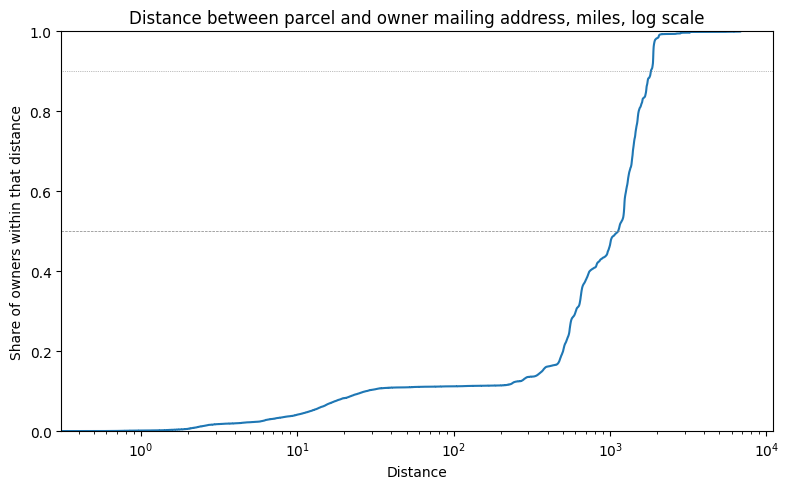

In [104]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.ecdfplot(data=unique_us_owners, x="owner_dist_mi", ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Distance")
ax.set_ylabel("Share of owners within that distance")
ax.set_title("Distance between parcel and owner mailing address, miles, log scale")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.5)
ax.axhline(0.9, color="gray", linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

In [105]:
dist = unique_us_owners["owner_dist_mi"].dropna()

summary = {
    "n_owners": len(dist),
    "median_mi": dist.median(),
    "mean_mi": dist.mean(),
    "pct_within_50mi": (dist <= 50).mean() * 100,
    "pct_within_100mi": (dist <= 100).mean() * 100,
    "pct_within_300mi": (dist <= 300).mean() * 100,
    "pct_over_500mi": (dist > 500).mean() * 100,
    "pct_over_1000mi": (dist > 1000).mean() * 100,
    "p10": dist.quantile(0.10),
    "p25": dist.quantile(0.25),
    "p75": dist.quantile(0.75),
    "p90": dist.quantile(0.90),
    "p95": dist.quantile(0.95),
    "max_mi": dist.max(),
}

for k, v in summary.items():
    print(f"{k}: {v:,.1f}" if isinstance(v, float) else f"{k}: {v}")

n_owners: 37747
median_mi: 1,124.3
mean_mi: 1,021.7
pct_within_50mi: 11.0
pct_within_100mi: 11.2
pct_within_300mi: 13.6
pct_over_500mi: 80.0
pct_over_1000mi: 53.3
p10: 27.5
p25: 549.4
p75: 1,457.1
p90: 1,822.3
p95: 1,891.9
max_mi: 6,824.6


In [106]:
for q in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    print(f"{int(q*100)}th percentile: {dist.quantile(q):.1f} mi")

10th percentile: 27.5 mi
20th percentile: 500.1 mi
30th percentile: 603.7 mi
40th percentile: 739.9 mi
50th percentile: 1124.3 mi
60th percentile: 1263.9 mi
70th percentile: 1398.5 mi
80th percentile: 1523.4 mi
90th percentile: 1822.3 mi
95th percentile: 1891.9 mi
99th percentile: 2057.3 mi


In [117]:
# find the trough/sparsest band of owner locations, to find a cutoff point between local and out-of-town owners

d = np.sort(unique_us_owners["owner_dist_mi"].dropna().to_numpy())

counts, edges = np.histogram(np.log10(d), bins=40)
mids = 10 ** ((edges[:-1] + edges[1:]) / 2)

mid = (mids > 30) & (mids < 1000)
i = np.flatnonzero(mid)[counts[mid].argmin()]
trough = mids[i]

print(f"sparsest bin: {trough:.0f} mi, {counts[i]:,} owners")
print(f"densest bin: {mids[counts.argmax()]:.0f} mi, {counts.max():,} owners")
print(f"below trough: {(d <= trough).mean():.1%}")
print(f"above trough: {(d >  trough).mean():.1%}")

sparsest bin: 106 mi, 23 owners
densest bin: 1452 mi, 8,135 owners
below trough: 11.2%
above trough: 88.8%


In [118]:
bands = [0, 80, 200, 500, 800, 1500, 2500, 3500, 5000, np.inf]
(unique_us_owners["owner_dist_mi"]
   .pipe(pd.cut, bands)
   .value_counts(normalize=True, sort=False)
   .mul(100).round(1))

owner_dist_mi
(0.0, 80.0]         11.1
(80.0, 200.0]        0.3
(200.0, 500.0]       8.6
(500.0, 800.0]      20.9
(800.0, 1500.0]     37.2
(1500.0, 2500.0]    21.2
(2500.0, 3500.0]     0.5
(3500.0, 5000.0]     0.0
(5000.0, inf]        0.1
Name: proportion, dtype: float64

Text(0, 0.5, 'Owners')

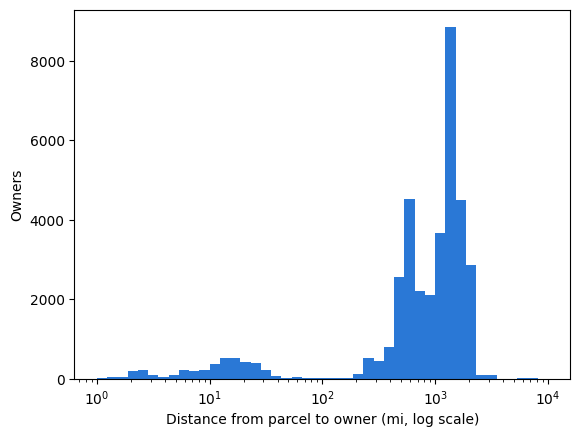

In [119]:
plt.hist(unique_us_owners["owner_dist_mi"].dropna(),
         bins=np.logspace(0, 4, 45), color="#2a78d6")
plt.xscale("log")
plt.xlabel("Distance from parcel to owner (mi, log scale)")
plt.ylabel("Owners")